In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

RANDSEED = 42
listmodel = {}

In [2]:
train_data = pd.read_csv('train.csv')
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test_data = pd.read_csv('test.csv')
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
train_data["Age"] = train_data["Age"].fillna(train_data["Age"].median())
train_data["Embarked"] = train_data["Embarked"].fillna(train_data["Embarked"].mode()[0])
train_data = train_data.drop(columns=["Cabin", "PassengerId", "Ticket"])

In [7]:
train_data["Title"] = train_data["Name"].str.extract(
    r" ([A-Za-z]+)\.",
    expand=False
)
train_data = train_data.drop(columns=["Name"])
train_data["Title"]

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 891, dtype: str

In [8]:
train_data["Sex"] = train_data["Sex"].map({
    "male": 0,
    "female": 1
})

In [9]:
# Mengubah kolom kategorikal "Embarked" menjadi beberapa kolom biner (One-Hot Encoding)
# Kategori Embarked terdiri dari:
# C = Cherbourg
# Q = Queenstown
# S = Southampton

# drop_first=True digunakan untuk menghapus satu kategori (C) sebagai kategori acuan (baseline).
# Alasannya karena jika ketiga kolom (C, Q, S) disimpan, akan terjadi dummy variable trap
# atau perfect multicollinearity, sebab nilai C selalu bisa dihitung dari Q dan S.
#
# Contoh:
# Q = 0 dan S = 0 -> C
# Q = 1 dan S = 0 -> Q
# Q = 0 dan S = 1 -> S
train_data = pd.get_dummies(
    train_data,
    columns=["Embarked"],
    drop_first=True
)

In [10]:
train_data = pd.get_dummies(
    train_data,
    columns=["Title"],
    drop_first=True
)


In [11]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Survived        891 non-null    int64  
 1   Pclass          891 non-null    int64  
 2   Sex             891 non-null    int64  
 3   Age             891 non-null    float64
 4   SibSp           891 non-null    int64  
 5   Parch           891 non-null    int64  
 6   Fare            891 non-null    float64
 7   Embarked_Q      891 non-null    bool   
 8   Embarked_S      891 non-null    bool   
 9   Title_Col       891 non-null    bool   
 10  Title_Countess  891 non-null    bool   
 11  Title_Don       891 non-null    bool   
 12  Title_Dr        891 non-null    bool   
 13  Title_Jonkheer  891 non-null    bool   
 14  Title_Lady      891 non-null    bool   
 15  Title_Major     891 non-null    bool   
 16  Title_Master    891 non-null    bool   
 17  Title_Miss      891 non-null    bool   
 18  T

In [12]:
corr = train_data.corr(numeric_only=True)
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title_Col,...,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir
0,0,3,0,22.0,1,0,7.2500,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,1,1,1,38.0,1,0,71.2833,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,1,3,1,26.0,0,0,7.9250,False,True,False,...,False,False,True,False,False,False,False,False,False,False
3,1,1,1,35.0,1,0,53.1000,False,True,False,...,False,False,False,False,False,False,True,False,False,False
4,0,3,0,35.0,0,0,8.0500,False,True,False,...,False,False,False,False,False,True,False,False,False,False


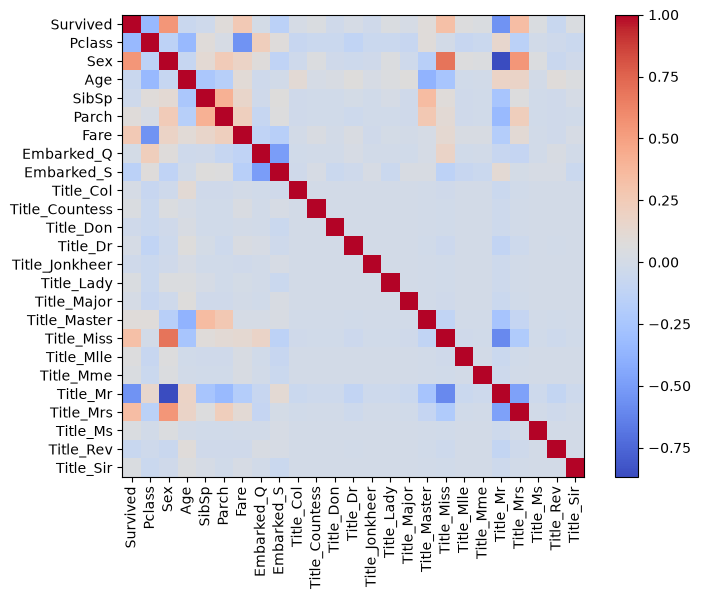

In [13]:
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [14]:
# pisahkan fitur dan target
X = train_data.drop("Survived", axis=1)
y = train_data["Survived"]

In [15]:
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDSEED)

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
# logreg model
model = LogisticRegression(random_state=RANDSEED)
model.fit(X_train, y_train)

y_pred_logreg = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_logreg))
print(confusion_matrix(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

Accuracy : 0.8156424581005587
[[89 16]
 [17 57]]
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       105
           1       0.78      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [18]:
# decision tree model
model = DecisionTreeClassifier(random_state=RANDSEED)
model.fit(X_train, y_train)
y_pred_dt = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.776536312849162
[[83 22]
 [18 56]]
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       105
           1       0.72      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [19]:
# random forest model
model = RandomForestClassifier(random_state=RANDSEED)
model.fit(X_train, y_train)
y_pred_rf = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.8268156424581006
[[89 16]
 [15 59]]
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       105
           1       0.79      0.80      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [20]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred_knn = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy : 0.8044692737430168
[[89 16]
 [19 55]]
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [21]:
model = SVC(random_state=RANDSEED)
model.fit(X_train, y_train)
y_pred_svm = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy : 0.8100558659217877
[[91 14]
 [20 54]]
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [22]:
results = pd.DataFrame({
    'Model': [
        'logistic regression',
        'decision tree',
        'Random Forest',
        'KNN',
        'SVM',
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
    ]
})

results

,Model,Accuracy
0,logistic regression,0.815642
1,decision tree,0.776536
2,Random Forest,0.826816
3,KNN,0.804469
4,SVM,0.810056
